# Geometry tests — NN bond patterns

For each lattice geometry we:
1. Build a nearest-neighbour Hamiltonian MPO via `build_hamiltonian`.
2. Extract the full matrix with `get_matrix` (feasible only for small `L`).
3. Plot the sites on a square grid indexed by **row-major** order
   (`n = ix + iy * Nx`, so column `ix` runs fastest) and draw a bond
   between every pair `(i, j)` with `|H[i,j]| > threshold`.

In [40]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

## Parameters and Hamiltonians

`Lx` and `Ly` are the **exponents**: the physical grid is `2^Lx × 2^Ly` sites.

In [4]:
Lx, Ly = 3, 3          # 4 × 4 = 16 sites
L  = Lx + Ly
Nx = 2^Lx
Ny = 2^Ly
N  = Nx * Ny

println("Grid: $(Nx) × $(Ny) = $(N) sites,  L = $(L) qubits")

Grid: 8 × 8 = 64 sites,  L = 6 qubits


In [ ]:
H_sq  = TensorBinding.get_Hamiltonian("square_2d",     1.0; L=L, Lx=Lx, Ly=Ly)
H_tri = TensorBinding.get_Hamiltonian("triangular_2d", 1.0; L=L, Lx=Lx, Ly=Ly)
H_hex = TensorBinding.get_Hamiltonian("hex_2d",        1.0; L=L, Lx=Lx, Ly=Ly)

## Extract full matrices

`build_hamiltonian` creates site indices internally, so we pull them from the MPO.

In [ ]:
M_sq  = TensorBinding.get_matrix(H_sq.mpo,  H_sq.sites)
M_tri = TensorBinding.get_matrix(H_tri.mpo, H_tri.sites)
M_hex = TensorBinding.get_matrix(H_hex.mpo, H_hex.sites)

println("Max off-diagonal (sq):  ", maximum(abs, M_sq  - Diagonal(diag(M_sq))))
println("Max off-diagonal (tri): ", maximum(abs, M_tri - Diagonal(diag(M_tri))))
println("Max off-diagonal (hex): ", maximum(abs, M_hex - Diagonal(diag(M_hex))))

## Plotting helper

Sites sit on an integer grid at `(ix, iy)` with `ix = n % Nx`, `iy = n ÷ Nx`.
A grey line is drawn for every pair `(i, j)` where `|H[i,j]| > threshold`.

In [4]:
function plot_bonds(M, Lx, Ly; title="", threshold=0.3)
    Nx = 2^Lx
    N  = 2^(Lx + Ly)

    # site coordinates (0-indexed, row-major)
    xs = Float64[n % Nx for n in 0:N-1]
    ys = Float64[n ÷ Nx for n in 0:N-1]

    plt = plot(; title=title, aspect_ratio=:equal, legend=false,
                 axis=false, grid=false,
                 xlims=(-0.7, Nx - 0.3), ylims=(-0.7, N÷Nx - 0.3))

    # bonds first so sites appear on top
    for i in 1:N, j in i+1:N
        if abs(M[i, j]) > threshold
            plot!(plt, [xs[i], xs[j]], [ys[i], ys[j]];
                  color=:gray, linewidth=2, alpha=0.8)
        end
    end

    # sites
    scatter!(plt, xs, ys;
             markersize=14, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5)

    # site labels (0-based linear index)
    for n in 0:N-1
        annotate!(plt, xs[n+1], ys[n+1],
                  text(string(n), 7, :white, :center))
    end

    return plt
end

plot_bonds (generic function with 1 method)

In [5]:
function plot_bonds_physical(M, rs; title="", threshold=0.3)
    xs_p = rs[:, 1]
    ys_p = rs[:, 2]
    N    = size(rs, 1)
    plt  = plot(; title=title, aspect_ratio=:equal, legend=false, axis=false, grid=false)
    for i in 1:N, j in i+1:N
        if abs(M[i, j]) > threshold
            plot!(plt, [xs_p[i], xs_p[j]], [ys_p[i], ys_p[j]];
                  color=:gray, linewidth=2, alpha=0.8)
        end
    end
    scatter!(plt, xs_p, ys_p;
             markersize=14, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5)
    for n in 0:N-1
        annotate!(plt, xs_p[n+1], ys_p[n+1], text(string(n), 7, :white, :center))
    end
    return plt
end

plot_bonds_physical (generic function with 1 method)

In [19]:
function geometry_matrix(H)
    n_sub   = H.sublattice_s === nothing ? 1 : ITensors.dim(H.sublattice_s)
    N_atoms = n_sub * H.N
    rs      = Matrix{Float64}(undef, N_atoms, 2)
    for i in 1:N_atoms; rs[i, :] = H.geometry(i); end
    return rs
end

geometry_matrix (generic function with 1 method)

## Square lattice

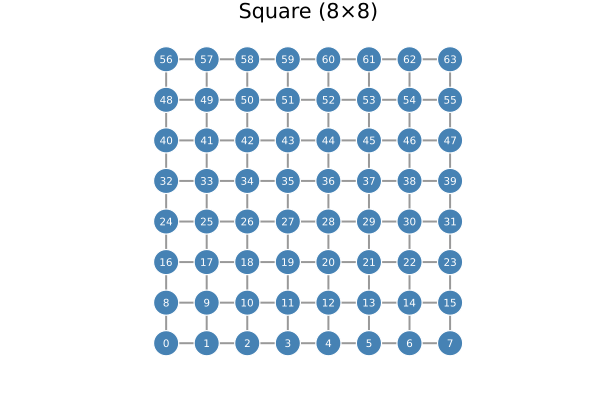

In [16]:
plot_bonds(real.(M_sq), Lx, Ly; title="Square ($(Nx)×$(Ny))")

## Square — physical positions

In [ ]:
plot_bonds_physical(real.(M_sq), geometry_matrix(H_sq);
                    title="Square physical positions ($(Nx)×$(Ny))")

## Triangular lattice

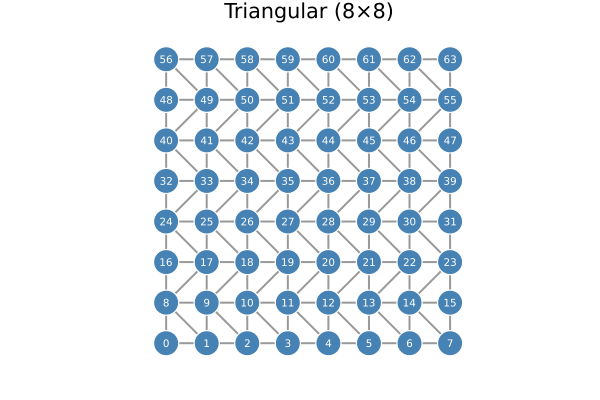

In [18]:
plot_bonds(real.(M_tri), Lx, Ly; title="Triangular ($(Nx)×$(Ny))")

## Triangular — physical positions

In [ ]:
plot_bonds_physical(real.(M_tri), geometry_matrix(H_tri);
                    title="Triangular physical positions ($(Nx)×$(Ny))")

## Honeycomb lattice

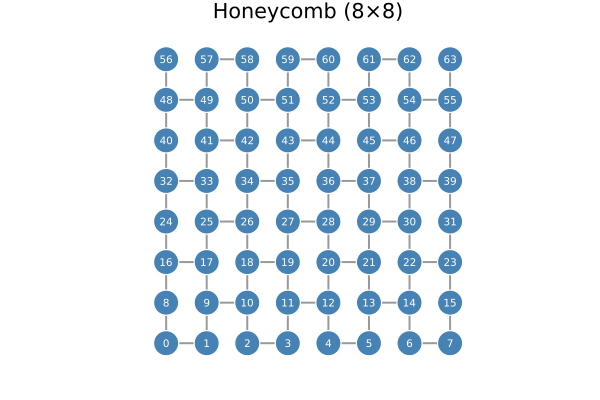

In [20]:
plot_bonds(real.(M_hex), Lx, Ly; title="Honeycomb ($(Nx)×$(Ny))")

## Honeycomb — physical positions

Same bond connectivity as above, but sites placed at their actual armchair-honeycomb coordinates.
`honeycomb_positions` maps each quantics index `n = ix + iy·Nx` to its physical `(x, y)`.

In [ ]:
plot_bonds_physical(real.(M_hex), geometry_matrix(H_hex);
                    title="Honeycomb physical positions ($(Nx)×$(Ny))")

## Kagomé lattice

Uses a smaller grid (`Lx_kag × Ly_kag` unit cells) since the total Hilbert space
is 3× larger (3 atoms per unit cell).  The sublattice index is postpended as a dim-3
"Kagome" site; `kagome_positions` returns the full real-space atom coordinates.

In [24]:
Lx_kag, Ly_kag = 2, 2    # 4×4 = 16 unit cells → 48 atoms total
H_kag = TensorBinding.get_Hamiltonian("kagome", 1.0; L=Lx_kag+Ly_kag, Lx=Lx_kag, Ly=Ly_kag)
M_kag = TensorBinding.get_matrix(H_kag.mpo, H_kag.sites)
println("Kagomé matrix size: $(size(M_kag))")
println("Max off-diagonal: ", maximum(abs, M_kag - Diagonal(diag(M_kag))))

Kagomé matrix size: (48, 48)
Max off-diagonal: 1.0000000000000018


## Kagomé — physical positions

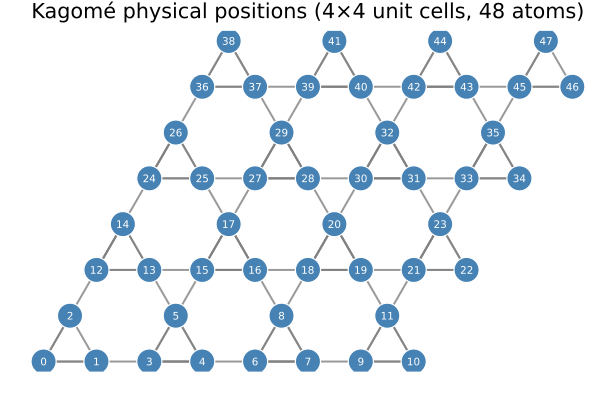

In [25]:
plot_bonds_physical(real.(M_kag), geometry_matrix(H_kag);
                    title="Kagomé physical positions ($(2^Lx_kag)×$(2^Ly_kag) unit cells, $(size(M_kag,1)) atoms)")

## Lieb lattice

Square Bravais lattice with 3 atoms per unit cell (A=corner, B=x-edge, C=y-edge).
Same grid size as kagomé: `Lx_lieb × Ly_lieb` unit cells → `3 × 2^(Lx+Ly)` atoms total.
The sublattice index is postpended as a dim-3 "Lieb" site; `lieb_positions` returns
the full real-space atom coordinates.

In [26]:
Lx_lieb, Ly_lieb = 2, 2    # 4×4 = 16 unit cells → 48 atoms total
H_lieb = TensorBinding.get_Hamiltonian("lieb", 1.0; L=Lx_lieb+Ly_lieb, Lx=Lx_lieb, Ly=Ly_lieb)
M_lieb = TensorBinding.get_matrix(H_lieb.mpo, H_lieb.sites)
println("Lieb matrix size: $(size(M_lieb))")
println("Max off-diagonal: ", maximum(abs, M_lieb - Diagonal(diag(M_lieb))))

Lieb matrix size: (48, 48)
Max off-diagonal: 1.0000000000000018


## Lieb — physical positions

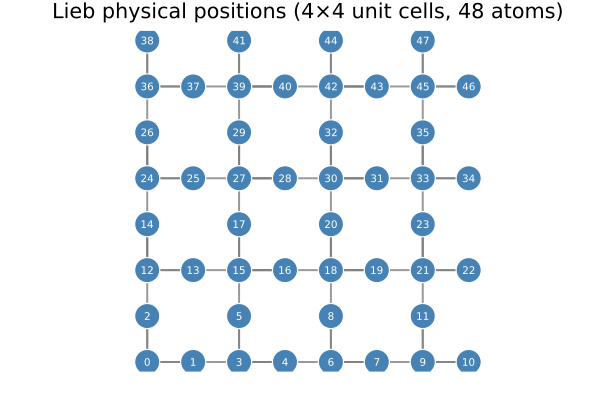

In [27]:
plot_bonds_physical(real.(M_lieb), geometry_matrix(H_lieb);
                    title="Lieb physical positions ($(2^Lx_lieb)×$(2^Ly_lieb) unit cells, $(size(M_lieb,1)) atoms)")

## Honeycomb (explicit sublattice)

Square Bravais lattice with 2 atoms per unit cell (A and B sublattices).
Same grid size as kagomé/Lieb: `Lx_hc × Ly_hc` unit cells → `2 × 2^(Lx+Ly)` atoms total.
The sublattice index is postpended as a dim-2 "Honeycomb" site; `honeycomb_sublattice_positions` returns
the full real-space atom coordinates.

In [ ]:
Lx_hc, Ly_hc = 2, 2    # 4×4 = 16 unit cells → 32 atoms total
H_hc = TensorBinding.get_Hamiltonian("honeycomb", 1.0; L=Lx_hc+Ly_hc, Lx=Lx_hc, Ly=Ly_hc)
M_hc = TensorBinding.get_matrix(H_hc.mpo, H_hc.sites)
println("Honeycomb sublattice matrix size: $(size(M_hc))")
println("Max off-diagonal: ", maximum(abs, M_hc - Diagonal(diag(M_hc))))

Honeycomb sublattice matrix size: (32, 32)
Max off-diagonal: 1.0000000000000029


## Honeycomb sublattice — physical positions

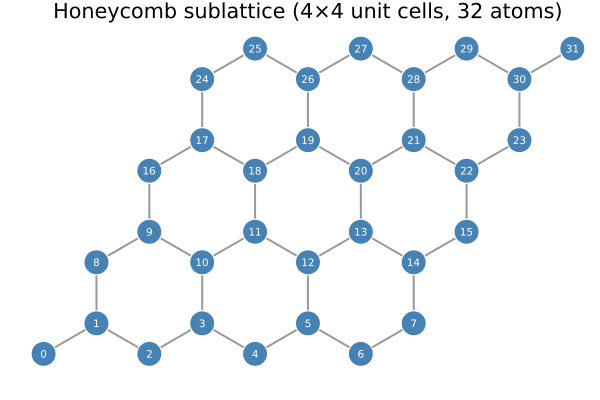

In [33]:
plot_bonds_physical(real.(M_hc), geometry_matrix(H_hc);
                    title="Honeycomb sublattice ($(2^Lx_hc)×$(2^Ly_hc) unit cells, $(size(M_hc,1)) atoms)")

## Dice (T3) lattice

Triangular Bravais lattice with 3 atoms per unit cell (A=hub coord-6, B=rim coord-3, C=rim coord-3).
Same grid size as kagomé/Lieb: `Lx_dice × Ly_dice` unit cells → `3 × 2^(Lx+Ly)` atoms total.
Atoms sit at 0, (a₁+a₂)/3, 2(a₁+a₂)/3 within each unit cell.
The sublattice index is postpended as a dim-3 "Dice" site; `dice_positions` returns
the full real-space atom coordinates.

In [46]:
Lx_dice, Ly_dice = 2, 2   # 4×4 = 16 unit cells → 48 atoms total
H_dice = TensorBinding.get_Hamiltonian("dice", 1.0; L=Lx_dice+Ly_dice, Lx=Lx_dice, Ly=Ly_dice)
M_dice = TensorBinding.get_matrix(H_dice.mpo, H_dice.sites)
println("Dice (T3) matrix size: $(size(M_dice))")
println("Max off-diagonal: ", maximum(abs, M_dice - Diagonal(diag(M_dice))))

Dice (T3) matrix size: (48, 48)
Max off-diagonal: 1.0000000000000064


## Dice (T3) — physical positions

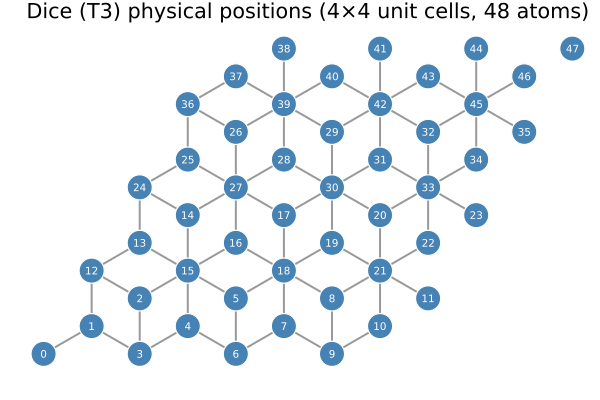

In [47]:
plot_bonds_physical(real.(M_dice), geometry_matrix(H_dice);
                    title="Dice (T3) physical positions ($(2^Lx_dice)×$(2^Ly_dice) unit cells, $(size(M_dice,1)) atoms)")

## All three side by side

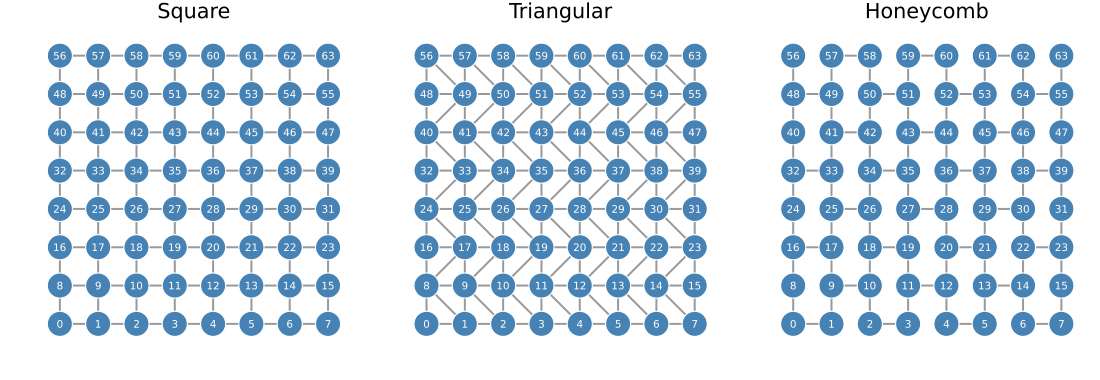

In [22]:
p1 = plot_bonds(real.(M_sq),  Lx, Ly; title="Square")
p2 = plot_bonds(real.(M_tri), Lx, Ly; title="Triangular")
p3 = plot_bonds(real.(M_hex), Lx, Ly; title="Honeycomb")
plot(p1, p2, p3; layout=(1, 3), size=(1100, 380))

In [ ]:
p1 = plot_bonds_physical(real.(M_sq),  geometry_matrix(H_sq),  title="Square physical positions ($(Nx)×$(Ny))")
p2 = plot_bonds_physical(real.(M_tri), geometry_matrix(H_tri), title="Triangular physical positions ($(Nx)×$(Ny))")
p3 = plot_bonds_physical(real.(M_hex), geometry_matrix(H_hex), title="Honeycomb physical positions ($(Nx)×$(Ny))")
plot(p1, p2, p3; layout=(1, 3), size=(1100, 380))

## Twisted square bilayer — physical positions

Layer 1 sits at 0°; layer 2 is rotated by `θ_deg` around the lattice centroid.
Intralayer bonds are drawn from the square Hamiltonian matrix.
Interlayer bonds are shown wherever `t_inter · exp(−α · |r₁ᵢ − r₂ⱼ|) > threshold`.

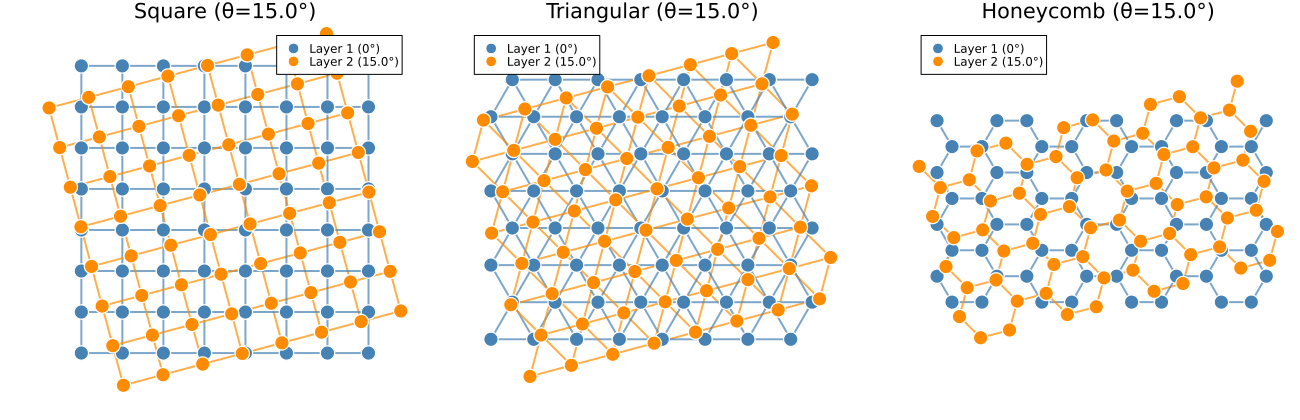

In [25]:
θ_deg = 15.0

function plot_twisted_intra(lattice_sym, M_intra, Lx, Ly, θ; title="")
    rs1 = TensorBinding.lattice_positions(lattice_sym, Lx, Ly; angle_deg=0.0)
    rs2 = TensorBinding.lattice_positions(lattice_sym, Lx, Ly; angle_deg=θ)
    N   = size(rs1, 1)
    plt = plot(; title=title, aspect_ratio=:equal, legend=:best, axis=false, grid=false)
    for i in 1:N, j in i+1:N
        if abs(M_intra[i, j]) > 0.3
            plot!(plt, [rs1[i,1], rs1[j,1]], [rs1[i,2], rs1[j,2]];
                  color=:steelblue, linewidth=2, alpha=0.7, label=false)
            plot!(plt, [rs2[i,1], rs2[j,1]], [rs2[i,2], rs2[j,2]];
                  color=:darkorange, linewidth=2, alpha=0.7, label=false)
        end
    end
    scatter!(plt, rs1[:,1], rs1[:,2]; markersize=8, color=:steelblue,
             markerstrokecolor=:white, markerstrokewidth=1.5, label="Layer 1 (0°)")
    scatter!(plt, rs2[:,1], rs2[:,2]; markersize=8, color=:darkorange,
             markerstrokecolor=:white, markerstrokewidth=1.5, label="Layer 2 ($(θ)°)")
    return plt
end

p1 = plot_twisted_intra(:square,     real.(M_sq),  Lx, Ly, θ_deg; title="Square (θ=$(θ_deg)°)")
p2 = plot_twisted_intra(:triangular, real.(M_tri), Lx, Ly, θ_deg; title="Triangular (θ=$(θ_deg)°)")
p3 = plot_twisted_intra(:honeycomb,  real.(M_hex), Lx, Ly, θ_deg; title="Honeycomb (θ=$(θ_deg)°)")
plot(p1, p2, p3; layout=(1, 3), size=(1300, 420))